# 🎬 TMDB Exploratory Data Analysis

This notebook loads the 5 tables from `movies.db`, merges them into a single DataFrame, then explores the data through 12 visualisations with observations.

**Prerequisites:** Run `tmdb_pipeline.py` first to populate `movies.db`.

In [2]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Seaborn theme for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
%matplotlib inline

print("Libraries loaded.")

Libraries loaded.


---
## 1. Load All Tables

In [3]:
conn = sqlite3.connect("movies.db")

df_movies       = pd.read_sql("SELECT * FROM movies", conn)
df_genres       = pd.read_sql("SELECT * FROM genres", conn)
df_movie_genres = pd.read_sql("SELECT * FROM movie_genres", conn)
df_cast         = pd.read_sql("SELECT * FROM cast", conn)
df_directors    = pd.read_sql("SELECT * FROM directors", conn)

conn.close()

for name, d in [("movies", df_movies), ("genres", df_genres),
                ("movie_genres", df_movie_genres), ("cast", df_cast),
                ("directors", df_directors)]:
    print(f"  {name:<15} {d.shape}")

  movies          (1604, 18)
  genres          (19, 2)
  movie_genres    (4456, 3)
  cast            (7937, 6)
  directors       (1602, 4)


---
## 2. Merge into One DataFrame

In [4]:
# Aggregate genres into comma-separated string per movie
genres_agg = (
    df_movie_genres.groupby("movie_id")["genre_name"]
    .agg(lambda x: ", ".join(sorted(x)))
    .reset_index()
    .rename(columns={"genre_name": "genres"})
)

# Aggregate top 5 cast into comma-separated string per movie
cast_agg = (
    df_cast.sort_values(["movie_id", "billing_order"])
    .groupby("movie_id")["actor_name"]
    .agg(lambda x: ", ".join(x))
    .reset_index()
    .rename(columns={"actor_name": "top_cast"})
)

directors_slim = df_directors[["movie_id", "director_name"]].copy()

# Merge everything
df = (
    df_movies
    .merge(genres_agg, on="movie_id", how="left")
    .merge(cast_agg, on="movie_id", how="left")
    .merge(directors_slim, on="movie_id", how="left")
)

# Clean: 0 means unreported, replace with NaN
df["budget"]  = df["budget"].replace(0, np.nan)
df["revenue"] = df["revenue"].replace(0, np.nan)

# Derived columns
df["profit"]  = df["revenue"] - df["budget"]
df["roi"]     = (df["profit"] / df["budget"]) * 100
df["decade"]  = (df["release_year"] // 10 * 10).astype("Int64")

print(f"Merged shape: {df.shape}")
print(f"\nNull counts in key columns:")
for col in ["budget", "revenue", "runtime", "director_name", "genres", "top_cast"]:
    print(f"  {col:<20} {df[col].isna().sum()}")

df.head(3)

Merged shape: (1604, 24)

Null counts in key columns:
  budget               264
  revenue              221
  runtime              0
  director_name        2
  genres               0
  top_cast             5


,movie_id,title,original_title,release_date,release_year,release_month,runtime,budget,revenue,vote_average,...,tagline,is_franchise,collection_name,fetched_at,genres,top_cast,director_name,profit,roi,decade
0,11,Star Wars,Star Wars,1977-05-25,1977,5,121,11000000.0,775398007.0,8.201,...,"A long time ago in a galaxy far, far away...",1,Star Wars Collection,2026-03-17T14:53:42.699306,"Action, Adventure, Science Fiction","Mark Hamill, Harrison Ford, Carrie Fisher, Pet...",George Lucas,764398007.0,6949.072791,1970
1,12,Finding Nemo,Finding Nemo,2003-05-30,2003,5,100,94000000.0,940335536.0,7.817,...,There are 3.7 trillion fish in the ocean. They...,1,Finding Nemo Collection,2026-03-17T14:53:47.274767,"Adventure, Animation, Family","Albert Brooks, Ellen DeGeneres, Alexander Goul...",Andrew Stanton,846335536.0,900.356953,2000
2,13,Forrest Gump,Forrest Gump,1994-06-23,1994,6,142,55000000.0,677387716.0,8.463,...,The world will never be the same once you've s...,0,None,2026-03-17T14:53:35.170258,"Comedy, Drama, Romance","Tom Hanks, Robin Wright, Gary Sinise, Sally Fi...",Robert Zemeckis,622387716.0,1131.614029,1990


---
## 3. EDA Plots & Observations

### Q1: Which genres have the most movies?

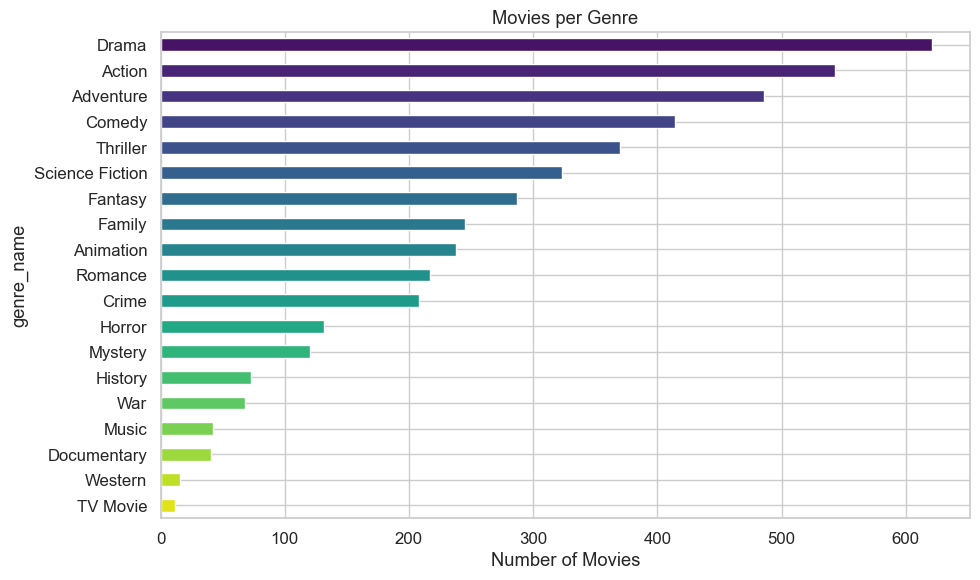

In [5]:
genre_counts = df_movie_genres["genre_name"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.plot.barh(ax=ax, color=sns.color_palette("viridis", len(genre_counts)))
ax.set_xlabel("Number of Movies")
ax.set_title("Movies per Genre")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** Drama dominates with ~621 movies, followed by Action (~543) and Adventure (~486). This reflects both TMDB's catalogue and our discovery strategy which favours high-vote-count films — blockbusters tend to be Action/Adventure, while Drama is the most common genre tag overall. Niche genres like Western, War, and Documentary are underrepresented because they rarely hit 200+ votes.

### Q2: Budget vs Revenue — does spending more earn more?

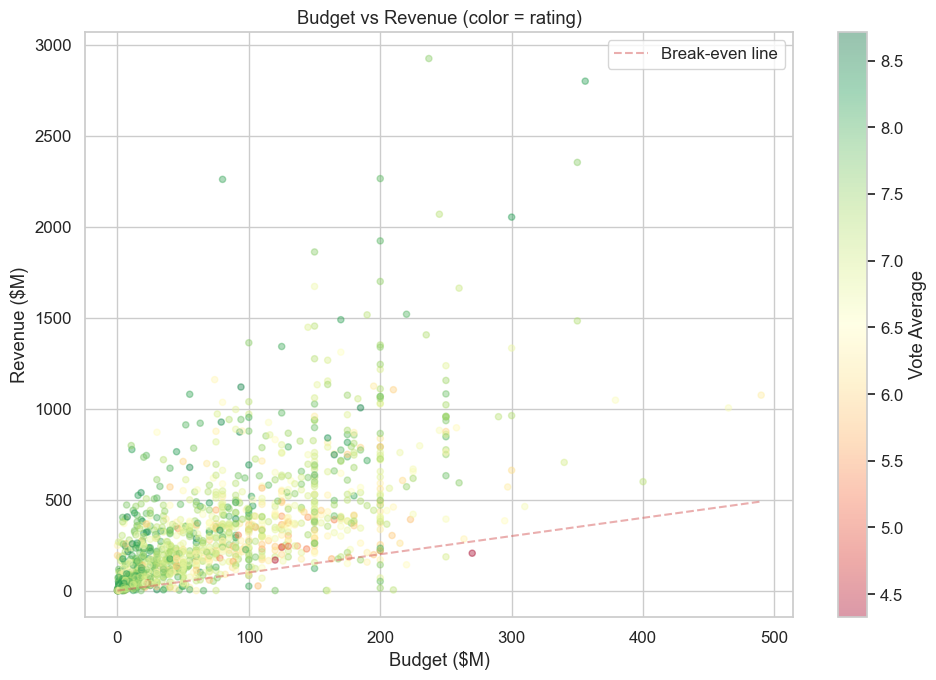

Pearson correlation (budget vs revenue): 0.655


In [6]:
fin = df.dropna(subset=["budget", "revenue"])

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(fin["budget"] / 1e6, fin["revenue"] / 1e6,
                     alpha=0.4, c=fin["vote_average"], cmap="RdYlGn", s=20)
ax.plot([0, fin["budget"].max() / 1e6], [0, fin["budget"].max() / 1e6],
        "r--", alpha=0.5, label="Break-even line")
ax.set_xlabel("Budget ($M)")
ax.set_ylabel("Revenue ($M)")
ax.set_title("Budget vs Revenue (color = rating)")
plt.colorbar(scatter, label="Vote Average")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation (budget vs revenue): {fin['budget'].corr(fin['revenue']):.3f}")

**Observation:** There's a moderate positive correlation (~0.655) between budget and revenue — bigger budgets tend to earn more, but it's far from guaranteed. Many points sit below the break-even line (red dashed), meaning they lost money. The colour gradient shows that high ratings (green) are scattered across all budget levels — you don't need a huge budget to make a well-rated film. A few extreme outliers (Avatar, Avengers) dominate the top-right corner.

### Q3: How are movie ratings distributed?

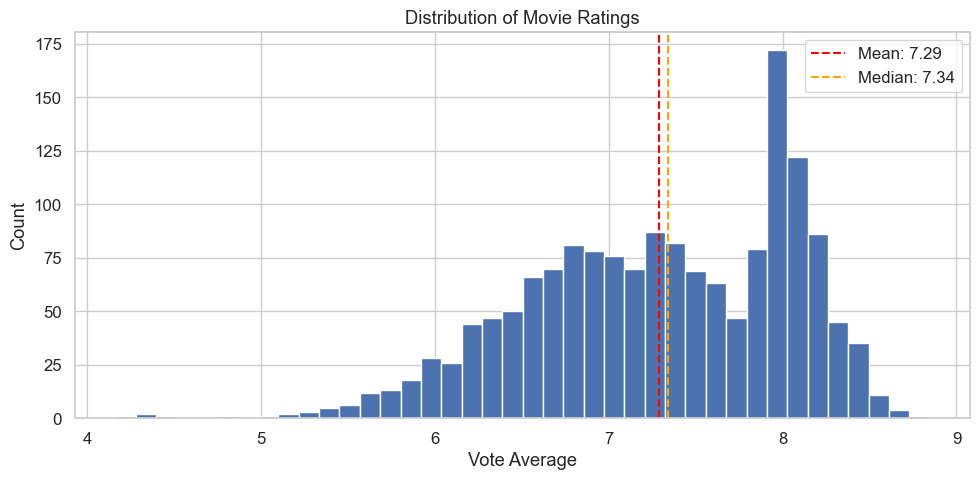

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["vote_average"].dropna(), bins=40, edgecolor="white", color="#4C72B0")
mean_val = df["vote_average"].mean()
median_val = df["vote_average"].median()
ax.axvline(mean_val, color="red", linestyle="--", label=f"Mean: {mean_val:.2f}")
ax.axvline(median_val, color="orange", linestyle="--", label=f"Median: {median_val:.2f}")
ax.set_xlabel("Vote Average")
ax.set_ylabel("Count")
ax.set_title("Distribution of Movie Ratings")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Ratings follow a roughly normal distribution centred around 7.3 (mean ≈ 7.29, median ≈ 7.34). The slight left skew means there are a few poorly-rated films pulling the mean down. Very few movies score below 5.0 or above 9.0. This is partly a selection bias — our `vote_count.gte=200` filter excluded obscure low-rated films that nobody watched.

### Q4: Revenue distribution by genre

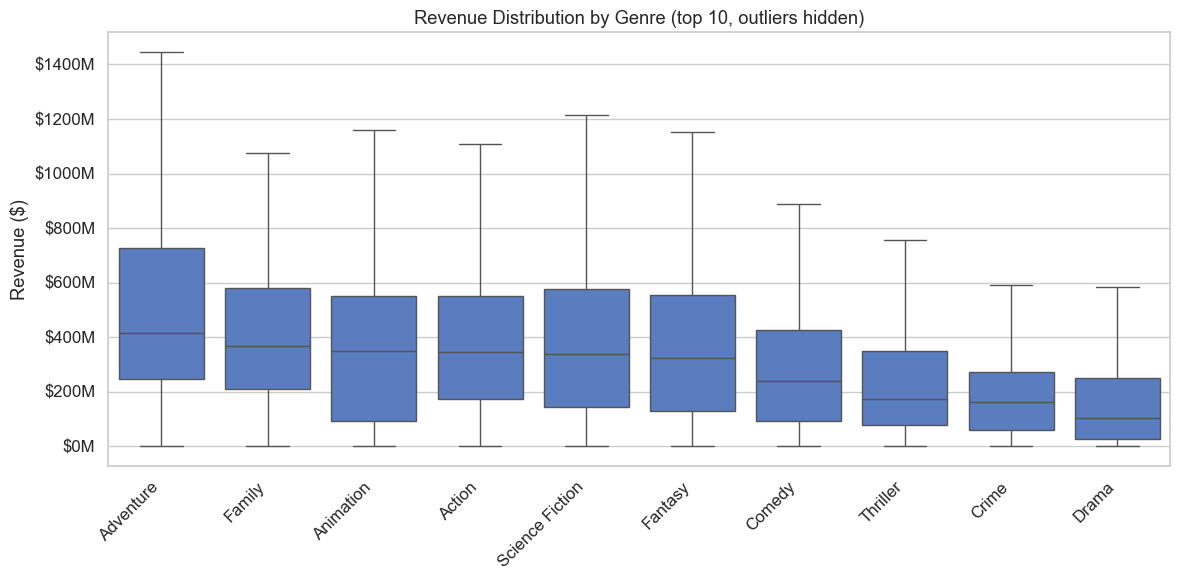

In [8]:
genre_rev = df_movie_genres.merge(df[["movie_id", "revenue"]], on="movie_id")
genre_rev = genre_rev.dropna(subset=["revenue"])

top_genres = genre_rev["genre_name"].value_counts().head(10).index
genre_rev_top = genre_rev[genre_rev["genre_name"].isin(top_genres)]

fig, ax = plt.subplots(figsize=(12, 6))
order = genre_rev_top.groupby("genre_name")["revenue"].median().sort_values(ascending=False).index
sns.boxplot(data=genre_rev_top, x="genre_name", y="revenue", order=order, ax=ax, showfliers=False)
ax.set_ylabel("Revenue ($)")
ax.set_xlabel("")
ax.set_title("Revenue Distribution by Genre (top 10, outliers hidden)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Adventure and Animation have the highest median revenues, driven by franchise blockbusters and family films with global appeal. Drama, despite being the most common genre, has a relatively low median revenue — many dramas are mid-budget films that don't chase box office numbers. The wide boxes for Action and Sci-Fi show high variance: some earn billions, others flop.

### Q5: How has average runtime changed over decades?

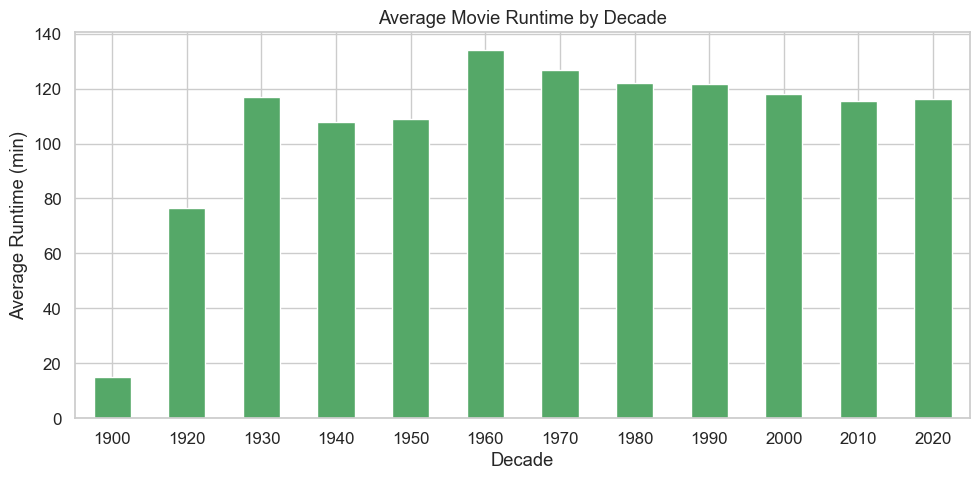

In [9]:
decade_runtime = df.dropna(subset=["decade", "runtime"]).groupby("decade")["runtime"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
decade_runtime.plot(kind="bar", ax=ax, color="#55A868", edgecolor="white")
ax.set_ylabel("Average Runtime (min)")
ax.set_xlabel("Decade")
ax.set_title("Average Movie Runtime by Decade")
ax.set_xticklabels([str(int(x)) for x in decade_runtime.index], rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Average runtime has been gradually decreasing from ~127 min in the 1970s to ~115 min in the 2010s, with a slight uptick in the 2020s (~116 min). The 1970s peak reflects the era of epic films (The Godfather, Apocalypse Now). The modern decline aligns with shorter attention spans and streaming-era pacing. The 2020s uptick may be driven by prestige films and superhero epics getting longer again.

### Q6: Franchise vs Standalone performance

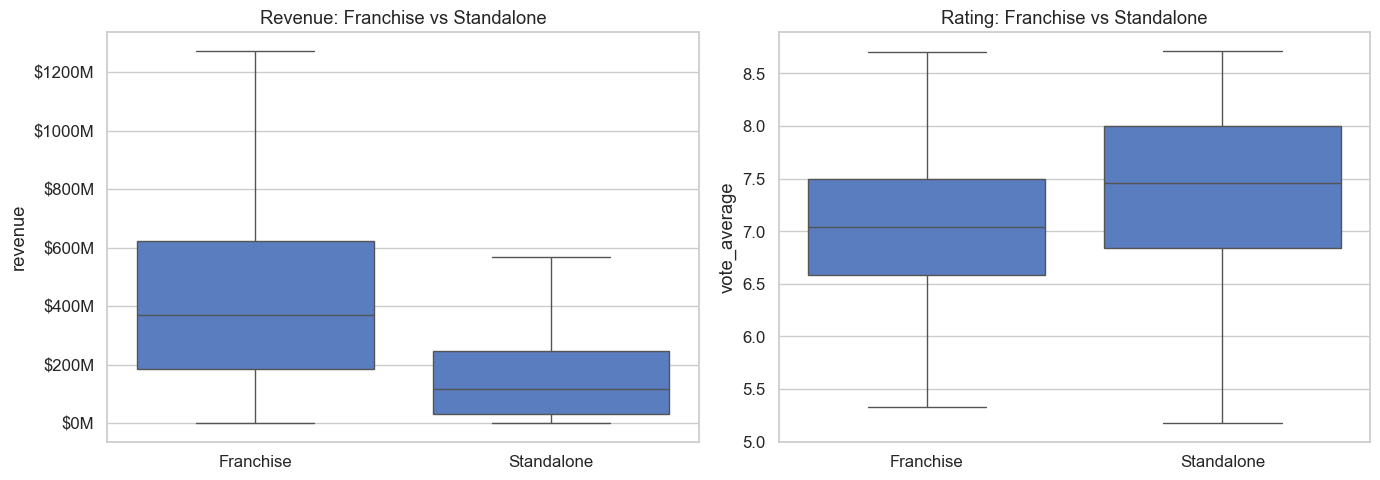

Median revenue — Franchise: $370M | Standalone: $117M


In [10]:
fran = df.dropna(subset=["revenue"]).copy()
fran["type"] = fran["is_franchise"].map({1: "Franchise", 0: "Standalone"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=fran, x="type", y="revenue", ax=axes[0], showfliers=False)
axes[0].set_title("Revenue: Franchise vs Standalone")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
axes[0].set_xlabel("")

sns.boxplot(data=fran, x="type", y="vote_average", ax=axes[1], showfliers=False)
axes[1].set_title("Rating: Franchise vs Standalone")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

print(f"Median revenue — Franchise: ${fran[fran['type']=='Franchise']['revenue'].median()/1e6:.0f}M | Standalone: ${fran[fran['type']=='Standalone']['revenue'].median()/1e6:.0f}M")

**Observation:** Franchise films earn dramatically more — median revenue of ~$370M vs ~$117M for standalone films (roughly 3x). However, ratings are nearly identical between the two groups. This tells us franchises are commercial machines (built-in audience, marketing momentum) but don't necessarily make *better* films. Studios invest in franchises for financial safety, not artistic quality.

### Q7: Best month to release a movie?

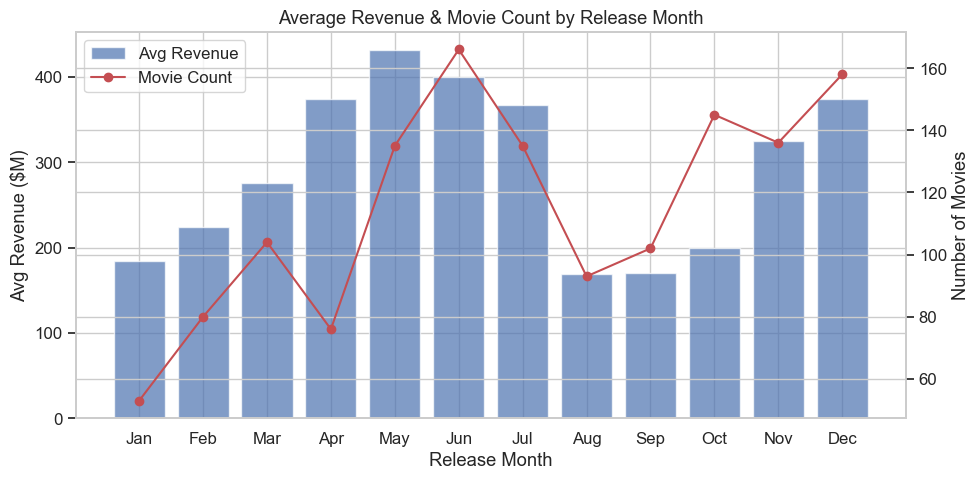

In [11]:
monthly = df.dropna(subset=["release_month", "revenue"]).groupby("release_month").agg(
    avg_revenue=("revenue", "mean"),
    movie_count=("movie_id", "count"),
).reset_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(monthly["release_month"], monthly["avg_revenue"] / 1e6, color="#4C72B0", alpha=0.7, label="Avg Revenue")
ax1.set_ylabel("Avg Revenue ($M)")
ax1.set_xlabel("Release Month")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_title("Average Revenue & Movie Count by Release Month")

ax2 = ax1.twinx()
ax2.plot(monthly["release_month"], monthly["movie_count"], "o-", color="#C44E52", label="Movie Count")
ax2.set_ylabel("Number of Movies")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

**Observation:** May and June are the highest-grossing release months (~$430M and ~$400M avg), corresponding to the summer blockbuster season. April is a strong third. September and January are the weakest months for revenue. Interestingly, the movie *count* is more evenly distributed — studios release films year-round, but they save their biggest tentpoles for summer. December also shows a bump (holiday releases).

### Q8: Top directors by average rating (min 3 films)

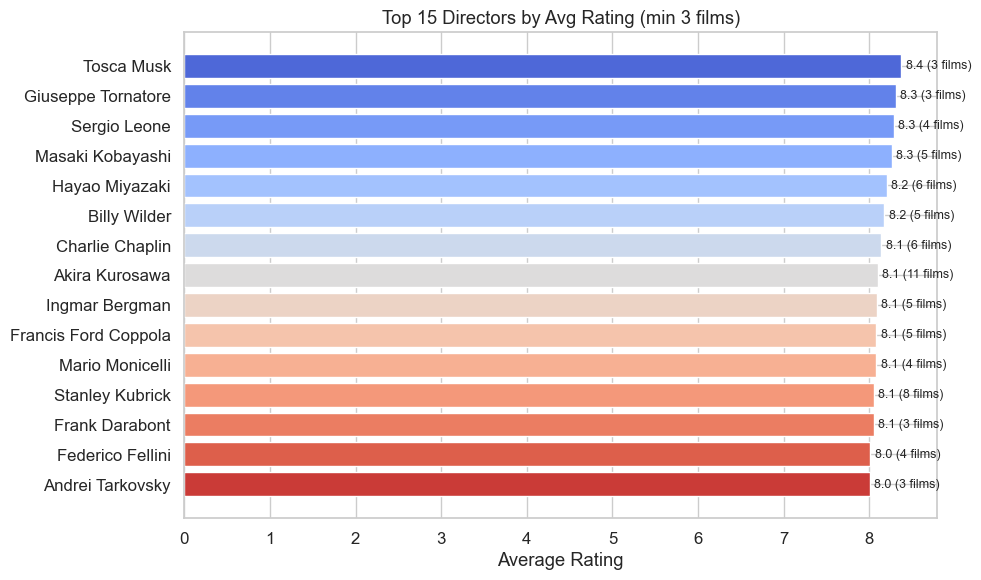

In [12]:
dir_stats = (
    df.dropna(subset=["director_name"])
    .groupby("director_name")
    .agg(films=("movie_id", "count"), avg_rating=("vote_average", "mean"))
    .query("films >= 3")
    .sort_values("avg_rating", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(dir_stats.index, dir_stats["avg_rating"], color=sns.color_palette("coolwarm", len(dir_stats)))
ax.set_xlabel("Average Rating")
ax.set_title("Top 15 Directors by Avg Rating (min 3 films)")
ax.invert_yaxis()
for i, (val, films) in enumerate(zip(dir_stats["avg_rating"], dir_stats["films"])):
    ax.text(val + 0.05, i, f"{val:.1f} ({films} films)", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** The top-rated directors include legends like Sergio Leone (4 films, avg 8.28) and Hayao Miyazaki (6 films, avg 8.20). Miyazaki stands out with the most films in the top tier — consistently excellent across a large body of work. The list skews toward auteur filmmakers rather than commercial directors, showing that critical acclaim and box office success don't always overlap.

### Q9: Most appearing actors (in top-5 billing)

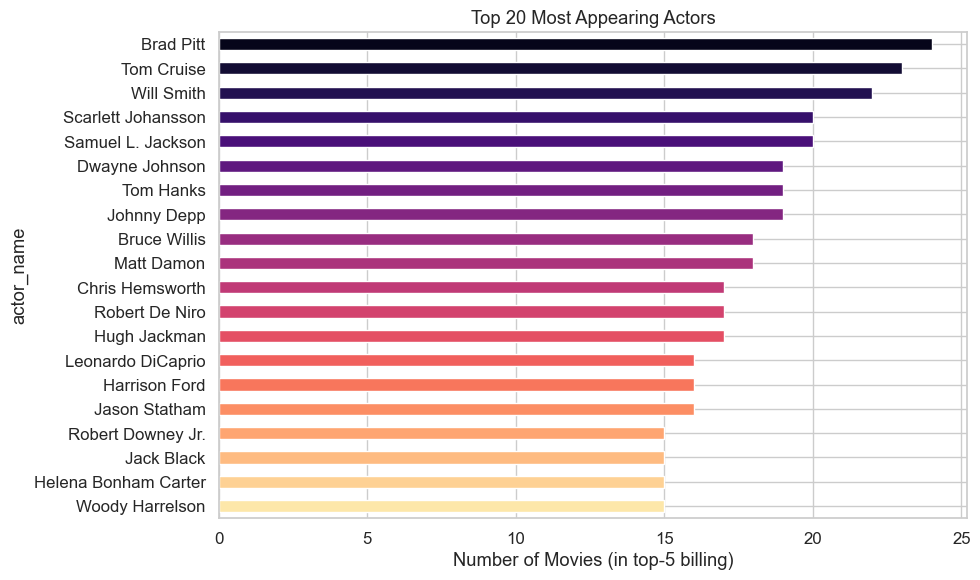

In [13]:
actor_counts = df_cast["actor_name"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
actor_counts.plot.barh(ax=ax, color=sns.color_palette("magma", len(actor_counts)))
ax.set_xlabel("Number of Movies (in top-5 billing)")
ax.set_title("Top 20 Most Appearing Actors")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** Brad Pitt leads with ~24 appearances in top-5 billing, followed closely by Tom Cruise (~23) and Will Smith (~22). Scarlett Johansson and Samuel L. Jackson round out the top 5 — Jackson's count is boosted by his prolific MCU appearances. This reflects both career longevity and a tendency to star in high-vote-count blockbusters (our dataset's selection bias).

### Q10: Correlation heatmap of numeric features

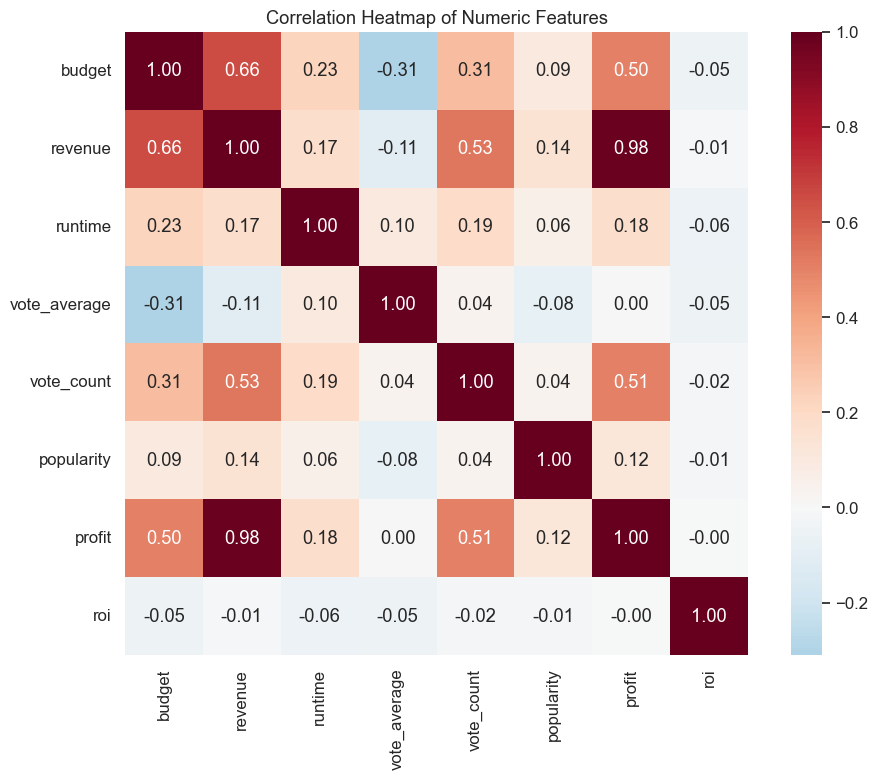

In [14]:
numeric_cols = ["budget", "revenue", "runtime", "vote_average", "vote_count", "popularity", "profit", "roi"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

**Observation:** Key correlations:
- **budget ↔ revenue (0.66):** Moderate positive — spending more tends to earn more, but not always.
- **vote_count ↔ revenue (high):** Popular movies get more votes *and* more revenue — they reinforce each other.
- **vote_average ↔ revenue (weak):** Good ratings don't strongly predict box office success. Critically acclaimed films can be niche.
- **ROI has low correlation with everything** — returns are unpredictable regardless of budget, rating, or popularity. This is why the film industry is considered high-risk.
- **runtime ↔ budget (moderate):** Longer films tend to cost more (more shooting days, VFX, etc.).

### Q11: Movies per year trend

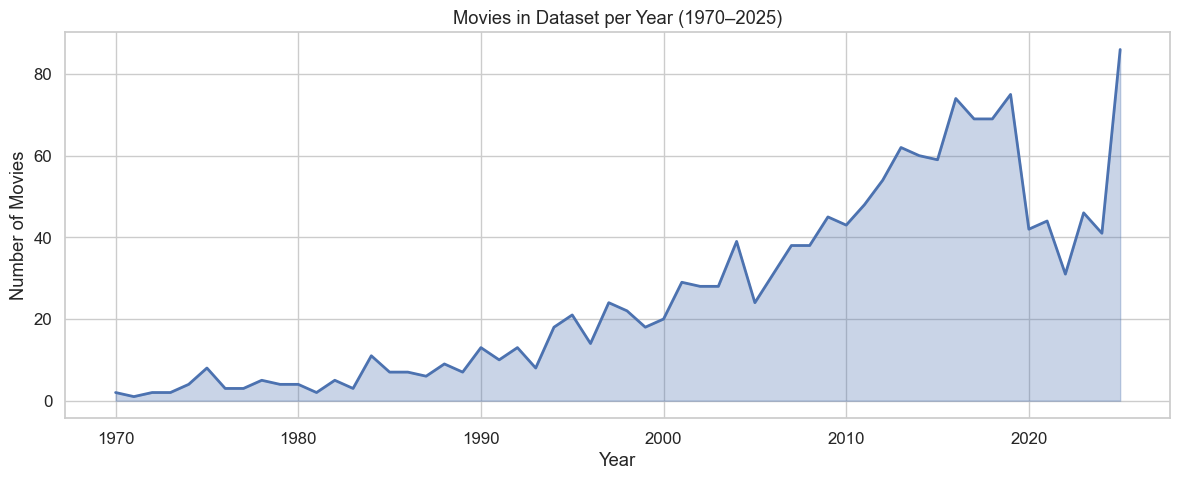

In [15]:
yearly = df.dropna(subset=["release_year"])
yearly = yearly[yearly["release_year"].between(1970, 2025)]
year_counts = yearly.groupby("release_year").size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(year_counts.index, year_counts.values, alpha=0.3, color="#4C72B0")
ax.plot(year_counts.index, year_counts.values, color="#4C72B0", linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Movies")
ax.set_title("Movies in Dataset per Year (1970–2025)")
plt.tight_layout()
plt.show()

**Observation:** The dataset has a clear recency bias — more movies from recent decades because modern films accumulate 200+ votes more easily. The count ramps up sharply from the 2000s onward. Pre-1990 coverage is sparse (only the most iconic films survive the vote threshold). You'll likely see a dip in 2020–2021 due to COVID-19 reducing theatrical releases. This distribution is important context: any time-based analysis should account for uneven year coverage.

### Q12: Top ROI movies — low budget, high return

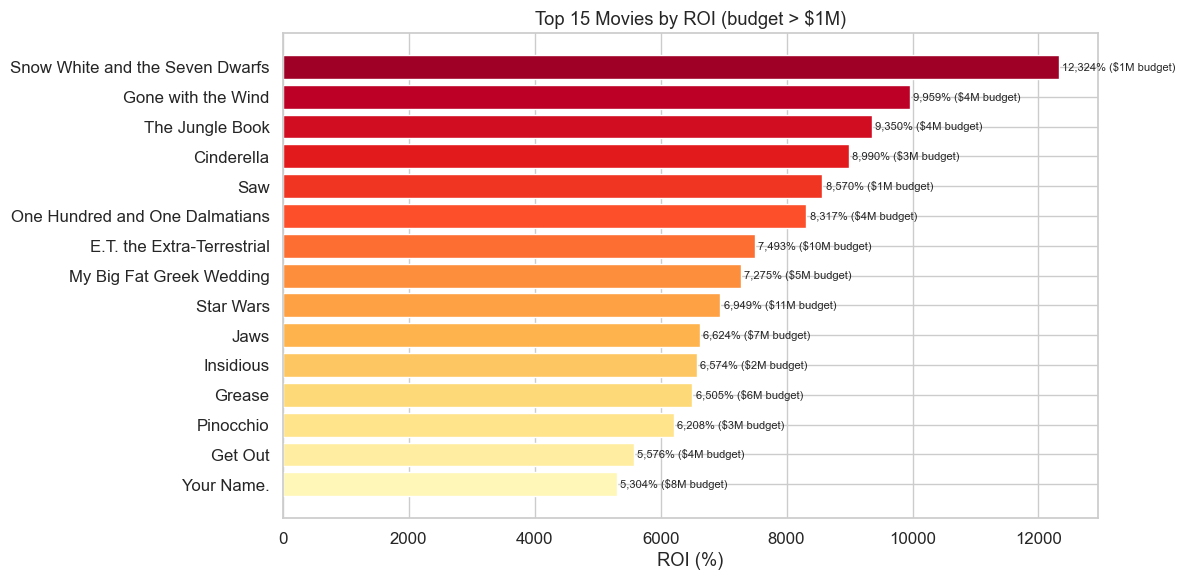

In [16]:
roi_df = df.dropna(subset=["roi", "budget"]).query("budget > 1e6").nlargest(15, "roi")

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(roi_df["title"], roi_df["roi"], color=sns.color_palette("YlOrRd_r", len(roi_df)))
ax.set_xlabel("ROI (%)")
ax.set_title("Top 15 Movies by ROI (budget > $1M)")
ax.invert_yaxis()
for i, (val, bud) in enumerate(zip(roi_df["roi"], roi_df["budget"])):
    ax.text(val + 50, i, f"{val:,.0f}% (${bud/1e6:.0f}M budget)", va="center", fontsize=8)
plt.tight_layout()
plt.show()

**Observation:** The highest-ROI films are typically horror or low-budget genre films that caught lightning in a bottle. These movies prove that you don't need a massive budget to generate enormous returns — a compelling concept and good execution can outperform $200M blockbusters on a percentage basis. Studios like Blumhouse have built entire business models around this insight: keep budgets low, and even modest box office becomes a huge win.

---
## Summary Statistics

In [17]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total movies:          {len(df):,}")
print(f"With budget data:      {df['budget'].notna().sum():,}")
print(f"With revenue data:     {df['revenue'].notna().sum():,}")
print(f"Year range:            {df['release_year'].min():.0f} – {df['release_year'].max():.0f}")
print(f"Avg rating:            {df['vote_average'].mean():.2f}")
print(f"Avg runtime:           {df['runtime'].mean():.0f} min")
print(f"Franchise movies:      {df['is_franchise'].sum():,} ({df['is_franchise'].mean()*100:.1f}%)")
print(f"Unique directors:      {df['director_name'].nunique():,}")
print(f"Unique actors:         {df_cast['actor_name'].nunique():,}")
print(f"\nLanguage breakdown:")
print(df["original_language"].value_counts().head(5).to_string())

DATASET SUMMARY
Total movies:          1,604
With budget data:      1,340
With revenue data:     1,383
Year range:            1902 – 2026
Avg rating:            7.29
Avg runtime:           117 min
Franchise movies:      692 (43.1%)
Unique directors:      854
Unique actors:         4,259

Language breakdown:
original_language
en    1330
ja      70
it      34
es      32
fr      28


---
## Key Takeaways for Students

1. **Budget ≠ Quality:** Higher budgets correlate with higher revenue but NOT with higher ratings.
2. **Franchises are cash machines:** ~3x the median revenue of standalone films, but similar ratings.
3. **Summer is king:** May/June releases earn the most on average — the blockbuster season is real.
4. **ROI favours the scrappy:** Low-budget films with a great concept can return 10,000%+ on investment.
5. **Data has biases:** Our vote_count filter creates selection bias toward popular English-language films (~83% English). Always acknowledge your data's limitations.
6. **0 ≠ zero:** Budget/revenue of 0 means *unreported*, not *free*. Cleaning this is critical before any analysis.
7. **Correlation ≠ causation:** Budget correlates with revenue, but spending more doesn't *cause* higher earnings — marketing, IP, and timing matter too.